<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/piste3bis_matrix_audit_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Test3bis / Piste 3bis — Heat-kernel broadening + matrix audit

Notebook Colab autonome corrigé.

Objectif : rendre Test3bis **auditable** en exportant explicitement :

- `L0.npz` : Laplacien de référence sans jitter ;
- `L.npz` : Laplacien jitteré ;
- `DeltaL.npz` : perturbation \( \Delta L=L-L_0 \) ;
- `jittered_conductances.csv` : conductances locales, résistances, jitter ;
- `matrix_stats.csv/json` : normes, erreurs d’identité, sommes de lignes ;
- `heat_trace_local.csv` : \(P(u)\), \(d_s(u)\) pour \(L_0\) et \(L\) ;
- `MATRIX_EXPORT_INDEX.csv` ;
- ZIP final exportable.

Statut : protocole numérique auditable, pas preuve analytique de convergence continuum.


In [1]:

# ============================================================
# 1. Imports, Colab Drive, directories
# ============================================================
import os, json, math, time, zipfile, platform, warnings
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.sparse import linalg as spla
from scipy.linalg import eigvalsh
from scipy.optimize import curve_fit

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=6, suppress=True)

try:
    from google.colab import drive, files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

USE_GOOGLE_DRIVE = True
DRIVE_ROOT = "/content/drive/MyDrive/ROSG_Test3bis"
LOCAL_OUT_DIR = Path("/content/piste3bis_matrix_audit_outputs")

if IN_COLAB and USE_GOOGLE_DRIVE:
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive", force_remount=True)
    OUT_DIR = Path(DRIVE_ROOT) / "piste3bis_matrix_audit_outputs"
else:
    OUT_DIR = LOCAL_OUT_DIR

OUT_DIR.mkdir(parents=True, exist_ok=True)
MATRIX_DIR = OUT_DIR / "matrix_exports"
FIG_DIR = OUT_DIR / "figures"
MATRIX_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

GLOBAL_SEED = 20260515

print("Python:", platform.python_version())
print("Running in Colab:", IN_COLAB)
print("OUT_DIR:", OUT_DIR)
print("MATRIX_DIR:", MATRIX_DIR)


Mounted at /content/drive
Python: 3.12.13
Running in Colab: True
OUT_DIR: /content/drive/MyDrive/ROSG_Test3bis/piste3bis_matrix_audit_outputs
MATRIX_DIR: /content/drive/MyDrive/ROSG_Test3bis/piste3bis_matrix_audit_outputs/matrix_exports


In [2]:

# ============================================================
# 2. Configuration
# ============================================================
@dataclass
class Track3bisConfig:
    # Small default values keep Colab runs manageable.
    # Increase n_subdiv/layers/n_z/n_realizations for production runs.
    n_subdiv: int = 3
    layers: int = 4
    torus_xy: bool = True
    torus_layers: bool = False

    z_min: float = -1.5
    z_max: float = 5.5
    n_z: int = 15
    n_realizations: int = 4

    w_plane: float = 1.0
    w_vertical_hi: float = 1.0
    w_vertical_lo: float = 0.0

    # Track 2bis RG-like conductance profile
    Z_th_RG: float = 1.328
    Delta_Z_RG: float = 0.515
    p_low_floor: float = 0.015
    p_high: float = 0.85

    # Local jitter
    jitter_sigma: float = 0.25
    hier_jitter_power: float = 1.0
    normalize_active_vertical_mean: bool = True

    # Heat trace reading window
    u_min: float = 0.08
    u_max: float = 80.0
    n_u: int = 34
    heat_window_q_low: float = 0.20
    heat_window_q_high: float = 0.80
    use_median_ds: bool = True

    # Exports
    export_matrices: bool = True
    export_eigenvalues: bool = True
    export_heat_trace_local: bool = True

CFG = Track3bisConfig()
Z_GRID = np.linspace(CFG.z_min, CFG.z_max, CFG.n_z)
U_GRID = np.logspace(np.log10(CFG.u_min), np.log10(CFG.u_max), CFG.n_u)

with open(OUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, indent=2)

print(json.dumps(asdict(CFG), indent=2))


{
  "n_subdiv": 3,
  "layers": 4,
  "torus_xy": true,
  "torus_layers": false,
  "z_min": -1.5,
  "z_max": 5.5,
  "n_z": 15,
  "n_realizations": 4,
  "w_plane": 1.0,
  "w_vertical_hi": 1.0,
  "w_vertical_lo": 0.0,
  "Z_th_RG": 1.328,
  "Delta_Z_RG": 0.515,
  "p_low_floor": 0.015,
  "p_high": 0.85,
  "jitter_sigma": 0.25,
  "hier_jitter_power": 1.0,
  "normalize_active_vertical_mean": true,
  "u_min": 0.08,
  "u_max": 80.0,
  "n_u": 34,
  "heat_window_q_low": 0.2,
  "heat_window_q_high": 0.8,
  "use_median_ds": true,
  "export_matrices": true,
  "export_eigenvalues": true,
  "export_heat_trace_local": true
}


In [3]:

# ============================================================
# 3. Profiles and fit helpers
# ============================================================
def m_rg(Z, cfg=CFG):
    return 0.5 * (1.0 + np.tanh((np.asarray(Z) - cfg.Z_th_RG) / cfg.Delta_Z_RG))

def active_probability(Z, cfg=CFG):
    return cfg.p_low_floor + (cfg.p_high - cfg.p_low_floor) * m_rg(Z, cfg)

def tanh_profile(Z, y_low, y_high, Z_th, Delta_Z):
    Z = np.asarray(Z, dtype=float)
    Delta_Z = max(abs(float(Delta_Z)), 1e-12)
    return y_low + 0.5 * (y_high - y_low) * (1.0 + np.tanh((Z - Z_th) / Delta_Z))

def logistic_profile(Z, y_low, y_high, Z_th, Delta_Z):
    Z = np.asarray(Z, dtype=float)
    Delta_Z = max(abs(float(Delta_Z)), 1e-12)
    x = np.clip(-2.0 * (Z - Z_th) / Delta_Z, -700, 700)
    return y_low + (y_high - y_low) / (1.0 + np.exp(x))

def aic_bic(y, yhat, k):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    n = len(y)
    rss = float(np.sum((y - yhat) ** 2))
    rss = max(rss, 1e-300)
    return rss, float(n*np.log(rss/n) + 2*k), float(n*np.log(rss/n) + k*np.log(n))

def fit_profile_models(df, y_col="ds_eff"):
    d = df[["Z", y_col]].dropna().sort_values("Z")
    Z = d["Z"].to_numpy(float)
    y = d[y_col].to_numpy(float)

    rows = []
    preds = pd.DataFrame({"Z": Z, y_col: y})

    # constant
    p = [float(np.mean(y))]
    yhat = np.zeros_like(y) + p[0]
    rss, aic, bic = aic_bic(y, yhat, 1)
    rows.append({"model": "constant", "rss": rss, "aic": aic, "bic": bic, "k": 1, "params": p})
    preds["constant"] = yhat

    # linear
    pp = np.polyfit(Z, y, 1)
    p = [float(pp[1]), float(pp[0])]
    yhat = p[0] + p[1] * Z
    rss, aic, bic = aic_bic(y, yhat, 2)
    rows.append({"model": "linear", "rss": rss, "aic": aic, "bic": bic, "k": 2, "params": p})
    preds["linear"] = yhat

    # sigmoid-like
    y_low0 = float(np.median(y[:max(2, len(y)//5)]))
    y_high0 = float(np.median(y[-max(2, len(y)//5):]))
    Z0 = float(Z[np.argmin(np.abs(y - 0.5*(y_low0+y_high0)))])
    D0 = 1.0
    ymin, ymax = float(np.min(y)), float(np.max(y))
    yr = max(ymax-ymin, 1e-6)
    bounds = ([ymin-yr, ymin-yr, Z.min()-2, 0.05],
              [ymax+yr, ymax+yr, Z.max()+2, 5.0])

    for name, func in [("tanh", tanh_profile), ("logistic", logistic_profile)]:
        try:
            popt, _ = curve_fit(func, Z, y, p0=[y_low0, y_high0, Z0, D0], bounds=bounds, maxfev=50000)
            yhat = func(Z, *popt)
            rss, aic, bic = aic_bic(y, yhat, 4)
            rows.append({"model": name, "rss": rss, "aic": aic, "bic": bic, "k": 4, "params": [float(x) for x in popt]})
            preds[name] = yhat
        except Exception as exc:
            rows.append({"model": name, "rss": np.inf, "aic": np.inf, "bic": np.inf, "k": 4, "params": None, "error": str(exc)})

    fit_df = pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)
    fit_df["delta_aic"] = fit_df["aic"] - fit_df["aic"].min()
    fit_df["delta_bic"] = fit_df["bic"] - fit_df["bic"].min()
    return fit_df, preds


In [4]:

# ============================================================
# 4. Cell-4 multiplex graph and Laplacian construction
# ============================================================
def node_id(x, y, layer, L_side, layers):
    return int(layer * L_side * L_side + y * L_side + x)

def add_edge(edges, u, v, edge_type, c_base):
    if u == v:
        return
    if u > v:
        u, v = v, u
    edges.append((u, v, edge_type, float(c_base)))

def build_cell4_base_edges(cfg=CFG):
    L_side = 2 ** cfg.n_subdiv
    n_nodes = L_side * L_side * cfg.layers
    edges = []

    # Four-neighbour cell-4 plane edges, no diagonals.
    for layer in range(cfg.layers):
        for y in range(L_side):
            for x in range(L_side):
                u = node_id(x, y, layer, L_side, cfg.layers)

                if x + 1 < L_side:
                    add_edge(edges, u, node_id(x+1, y, layer, L_side, cfg.layers), "plane", cfg.w_plane)
                elif cfg.torus_xy:
                    add_edge(edges, u, node_id(0, y, layer, L_side, cfg.layers), "plane", cfg.w_plane)

                if y + 1 < L_side:
                    add_edge(edges, u, node_id(x, y+1, layer, L_side, cfg.layers), "plane", cfg.w_plane)
                elif cfg.torus_xy:
                    add_edge(edges, u, node_id(x, 0, layer, L_side, cfg.layers), "plane", cfg.w_plane)

    # Vertical multiplex candidates
    for layer in range(cfg.layers - 1):
        for y in range(L_side):
            for x in range(L_side):
                u = node_id(x, y, layer, L_side, cfg.layers)
                v = node_id(x, y, layer+1, L_side, cfg.layers)
                add_edge(edges, u, v, "vertical_candidate", cfg.w_vertical_hi)

    if cfg.torus_layers and cfg.layers > 2:
        for y in range(L_side):
            for x in range(L_side):
                u = node_id(x, y, cfg.layers-1, L_side, cfg.layers)
                v = node_id(x, y, 0, L_side, cfg.layers)
                add_edge(edges, u, v, "vertical_candidate", cfg.w_vertical_hi)

    edge_df = pd.DataFrame(edges, columns=["u", "v", "edge_type", "c_base"]).drop_duplicates(["u", "v", "edge_type"])
    edge_df["edge_id"] = np.arange(len(edge_df), dtype=int)
    return n_nodes, edge_df

def realize_jittered_conductances(Z, realization, cfg=CFG):
    n_nodes, base_edges = build_cell4_base_edges(cfg)
    rng = np.random.default_rng(GLOBAL_SEED + 100000*realization + int(round((Z+10)*1000)))
    df = base_edges.copy()

    p = float(active_probability(Z, cfg))
    is_vertical = df["edge_type"].eq("vertical_candidate").to_numpy()
    is_plane = df["edge_type"].eq("plane").to_numpy()

    active = np.zeros(len(df), dtype=bool)
    active[is_plane] = True
    active[is_vertical] = rng.random(is_vertical.sum()) < p
    df["active"] = active

    c0 = np.zeros(len(df), dtype=float)
    c0[is_plane & active] = cfg.w_plane
    c0[is_vertical & active] = cfg.w_vertical_lo + (cfg.w_vertical_hi - cfg.w_vertical_lo) * float(m_rg(Z, cfg))

    jitter_factor = np.ones(len(df), dtype=float)
    amp = cfg.jitter_sigma * (1.0 + cfg.hier_jitter_power * (1.0 - float(m_rg(Z, cfg))))
    jitter_factor[is_vertical & active] = np.exp(
        rng.normal(loc=-0.5*amp*amp, scale=amp, size=(is_vertical & active).sum())
    )

    c = c0.copy()
    c[is_vertical & active] = c0[is_vertical & active] * jitter_factor[is_vertical & active]

    if cfg.normalize_active_vertical_mean and np.any(is_vertical & active):
        target = np.mean(c0[is_vertical & active])
        current = np.mean(c[is_vertical & active])
        if current > 0:
            c[is_vertical & active] *= target / current

    df["p_active_vertical"] = p
    df["m_rg"] = float(m_rg(Z, cfg))
    df["c_baseline"] = c0
    df["jitter_factor"] = jitter_factor
    df["conductance"] = c
    df["resistance"] = np.where(c > 0, 1.0 / np.maximum(c, 1e-300), np.inf)
    df["Z"] = float(Z)
    df["realization"] = int(realization)
    return n_nodes, df

def laplacian_from_edge_df(n_nodes, edge_df, conductance_col="conductance"):
    active = edge_df[edge_df[conductance_col] > 0].copy()
    u = active["u"].to_numpy(int)
    v = active["v"].to_numpy(int)
    w = active[conductance_col].to_numpy(float)

    rows = np.concatenate([u, v, u, v])
    cols = np.concatenate([v, u, u, v])
    data = np.concatenate([-w, -w, w, w])

    L = sparse.coo_matrix((data, (rows, cols)), shape=(n_nodes, n_nodes)).tocsr()
    L.sum_duplicates()
    return L

def build_L0_L_DeltaL(Z, realization, cfg=CFG):
    n_nodes, edge_df = realize_jittered_conductances(Z, realization, cfg)
    L0 = laplacian_from_edge_df(n_nodes, edge_df, "c_baseline")
    L = laplacian_from_edge_df(n_nodes, edge_df, "conductance")
    DeltaL = L - L0
    return L0, L, DeltaL, edge_df


In [5]:

# ============================================================
# 5. Heat trace and spectral dimension
# ============================================================
def laplacian_eigenvalues(L):
    # Dense eigensolver is acceptable for default Colab size.
    # For larger production graphs, replace with sparse Lanczos / stochastic trace.
    dense = L.toarray() if sparse.issparse(L) else np.asarray(L)
    vals = eigvalsh(dense)
    return np.maximum(vals, 0.0)

def heat_trace_from_eigs(eigs, u_grid=U_GRID):
    eigs = np.asarray(eigs, dtype=float)
    return np.array([np.mean(np.exp(-u * eigs)) for u in u_grid], dtype=float)

def ds_curve_from_heat(P, u_grid=U_GRID):
    P = np.maximum(np.asarray(P, dtype=float), 1e-300)
    logP = np.log(P)
    logu = np.log(u_grid)
    return -2.0 * np.gradient(logP, logu)

def effective_ds(ds_curve, cfg=CFG):
    ds = np.asarray(ds_curve, dtype=float)
    lo = int(math.floor(cfg.heat_window_q_low * len(ds)))
    hi = int(math.ceil(cfg.heat_window_q_high * len(ds)))
    hi = max(hi, lo + 3)
    win = ds[lo:hi]
    return {
        "ds_eff_mean": float(np.mean(win)),
        "ds_eff_median": float(np.median(win)),
        "ds_eff_std": float(np.std(win)),
        "window_points": int(len(win)),
        "window_i_min": int(lo),
        "window_i_max": int(hi-1),
        "u_window_min": float(U_GRID[lo]),
        "u_window_max": float(U_GRID[hi-1]),
    }

def compute_spectral_observables(L, cfg=CFG):
    eigs = laplacian_eigenvalues(L)
    P = heat_trace_from_eigs(eigs, U_GRID)
    ds = ds_curve_from_heat(P, U_GRID)
    eff = effective_ds(ds, cfg)
    eff["lambda_0"] = float(eigs[0])
    eff["lambda_1"] = float(eigs[1]) if len(eigs) > 1 else np.nan
    eff["lambda_max"] = float(eigs[-1])
    return eigs, P, ds, eff


In [6]:

# ============================================================
# 6. Matrix / conductance export bundle
# ============================================================
def sparse_fro_norm(A):
    return float(np.sqrt(A.multiply(A).sum()))

def safe_op_norm(A):
    try:
        if A.nnz == 0:
            return 0.0
        return float(spla.norm(A, ord=2))
    except Exception:
        return np.nan

def export_matrix_bundle(tag, Z, realization, L0, L, DeltaL, edge_df, eigs0=None, eigs=None, cfg=CFG):
    if not cfg.export_matrices:
        return {}

    prefix = f"{tag}_Z{Z:.4f}_r{realization:03d}".replace("-", "m").replace(".", "p")
    bundle_dir = MATRIX_DIR / prefix
    bundle_dir.mkdir(parents=True, exist_ok=True)

    L0 = sparse.csr_matrix(L0)
    L = sparse.csr_matrix(L)
    DeltaL = sparse.csr_matrix(DeltaL)

    sparse.save_npz(bundle_dir / f"{prefix}_L0.npz", L0)
    sparse.save_npz(bundle_dir / f"{prefix}_L.npz", L)
    sparse.save_npz(bundle_dir / f"{prefix}_DeltaL.npz", DeltaL)
    edge_df.to_csv(bundle_dir / f"{prefix}_jittered_conductances.csv", index=False)

    if eigs0 is not None and cfg.export_eigenvalues:
        pd.DataFrame({"lambda_L0": eigs0}).to_csv(bundle_dir / f"{prefix}_eigenvalues_L0.csv", index=False)
    if eigs is not None and cfg.export_eigenvalues:
        pd.DataFrame({"lambda_L": eigs}).to_csv(bundle_dir / f"{prefix}_eigenvalues_L.csv", index=False)

    norm_L0 = sparse_fro_norm(L0)
    norm_L = sparse_fro_norm(L)
    norm_D = sparse_fro_norm(DeltaL)
    diff_check = sparse_fro_norm(DeltaL - (L - L0))
    row_sum_L = float(np.max(np.abs(np.asarray(L.sum(axis=1)).ravel())))
    row_sum_L0 = float(np.max(np.abs(np.asarray(L0.sum(axis=1)).ravel())))

    active = edge_df[edge_df["conductance"] > 0]
    vert = active[active["edge_type"].eq("vertical_candidate")]

    stats = {
        "tag": tag,
        "Z": float(Z),
        "realization": int(realization),
        "n_nodes": int(L.shape[0]),
        "nnz_L0": int(L0.nnz),
        "nnz_L": int(L.nnz),
        "nnz_DeltaL": int(DeltaL.nnz),
        "norm_L0_fro": norm_L0,
        "norm_L_fro": norm_L,
        "norm_DeltaL_fro": norm_D,
        "relative_DeltaL_fro": float(norm_D / max(norm_L0, 1e-15)),
        "norm_DeltaL_op_est": safe_op_norm(DeltaL),
        "delta_identity_error_fro": diff_check,
        "max_abs_row_sum_L0": row_sum_L0,
        "max_abs_row_sum_L": row_sum_L,
        "n_active_edges": int(len(active)),
        "n_active_vertical_edges": int(len(vert)),
        "vertical_conductance_mean": float(vert["conductance"].mean()) if len(vert) else 0.0,
        "vertical_conductance_std": float(vert["conductance"].std()) if len(vert) > 1 else 0.0,
        "vertical_jitter_factor_mean": float(vert["jitter_factor"].mean()) if len(vert) else 1.0,
        "vertical_jitter_factor_std": float(vert["jitter_factor"].std()) if len(vert) > 1 else 0.0,
    }

    pd.DataFrame([stats]).to_csv(bundle_dir / f"{prefix}_matrix_stats.csv", index=False)
    with open(bundle_dir / f"{prefix}_matrix_stats.json", "w", encoding="utf-8") as f:
        json.dump(stats, f, indent=2)

    return stats


In [7]:

# ============================================================
# 7. Single realization and scan runner
# ============================================================
def run_single_realization(Z, realization, tag="test3bis_matrix_audit", cfg=CFG):
    L0, L, DeltaL, edge_df = build_L0_L_DeltaL(Z, realization, cfg)

    eigs0, P0, ds0, eff0 = compute_spectral_observables(L0, cfg)
    eigs, P, ds, eff = compute_spectral_observables(L, cfg)

    matrix_stats = export_matrix_bundle(tag, Z, realization, L0, L, DeltaL, edge_df, eigs0, eigs, cfg)

    prefix = f"{tag}_Z{Z:.4f}_r{realization:03d}".replace("-", "m").replace(".", "p")
    trace_dir = MATRIX_DIR / prefix
    trace_dir.mkdir(parents=True, exist_ok=True)

    if cfg.export_heat_trace_local:
        pd.DataFrame({
            "u": U_GRID,
            "log_u": np.log(U_GRID),
            "P_L0": P0,
            "P_L": P,
            "ds_u_L0": ds0,
            "ds_u_L": ds,
        }).to_csv(trace_dir / f"{prefix}_heat_trace_local.csv", index=False)

    return {
        "tag": tag,
        "Z": float(Z),
        "realization": int(realization),
        "ds_eff_mean_L0": eff0["ds_eff_mean"],
        "ds_eff_median_L0": eff0["ds_eff_median"],
        "ds_eff_std_L0": eff0["ds_eff_std"],
        "ds_eff_mean_L": eff["ds_eff_mean"],
        "ds_eff_median_L": eff["ds_eff_median"],
        "ds_eff_std_L": eff["ds_eff_std"],
        "delta_ds_mean": eff["ds_eff_mean"] - eff0["ds_eff_mean"],
        "delta_ds_median": eff["ds_eff_median"] - eff0["ds_eff_median"],
        "lambda1_L0": eff0["lambda_1"],
        "lambda1_L": eff["lambda_1"],
        "lambda_max_L0": eff0["lambda_max"],
        "lambda_max_L": eff["lambda_max"],
        "window_points": eff["window_points"],
        **{f"matrix_{k}": v for k, v in matrix_stats.items() if k not in ["tag", "Z", "realization"]},
    }

def run_scan(cfg=CFG, tag="test3bis_matrix_audit"):
    rows = []
    t0 = time.time()

    for iz, Z in enumerate(Z_GRID, start=1):
        for r in range(cfg.n_realizations):
            rows.append(run_single_realization(float(Z), r, tag=tag, cfg=cfg))

        if iz % max(1, len(Z_GRID)//5) == 0 or iz == len(Z_GRID):
            print(f"[scan] {iz}/{len(Z_GRID)} Z values done | rows={len(rows)} | elapsed={time.time()-t0:.1f}s")

        pd.DataFrame(rows).to_csv(OUT_DIR / f"{tag}_raw.csv", index=False)

    return pd.DataFrame(rows)


In [8]:

# ============================================================
# 8. Run main scan
# ============================================================
RUN_MAIN_SCAN = True

if RUN_MAIN_SCAN:
    raw = run_scan(CFG, tag="test3bis_matrix_audit")
else:
    raw = pd.read_csv(OUT_DIR / "test3bis_matrix_audit_raw.csv")

raw.head()


[scan] 3/15 Z values done | rows=12 | elapsed=2.5s
[scan] 6/15 Z values done | rows=24 | elapsed=9.4s
[scan] 9/15 Z values done | rows=36 | elapsed=11.7s


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited at iteration 20 with accuracies 
[0.000094]
not reaching the requested tolerance 3.814697265625e-06.
Use iteration 19 instead with accuracy 
4.903456510554778e-05.

  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited postprocessing with accuracies 
[0.000049]
not reaching the requested tolerance 3.814697265625e-06.
  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,


[scan] 12/15 Z values done | rows=48 | elapsed=14.2s


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited at iteration 20 with accuracies 
[0.000694]
not reaching the requested tolerance 3.814697265625e-06.
Use iteration 21 instead with accuracy 
0.0006937024306215478.

  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited postprocessing with accuracies 
[0.000694]
not reaching the requested tolerance 3.814697265625e-06.
  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: UserWarning: Exited at iteration 20 with accuracies 
[0.000007]
not reaching the requested tolerance 3.814697265625e-06.
Use iteration 21 instead with accuracy 
6.511287993924268e-06.

  _, eigvec = lobpcg(XH_X, X, tol=tol ** 2, maxiter=maxiter,
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_eigen/_svds.py:477: Use

[scan] 15/15 Z values done | rows=60 | elapsed=16.6s


,tag,Z,realization,ds_eff_mean_L0,ds_eff_median_L0,ds_eff_std_L0,ds_eff_mean_L,ds_eff_median_L,ds_eff_std_L,delta_ds_mean,...,matrix_norm_DeltaL_op_est,matrix_delta_identity_error_fro,matrix_max_abs_row_sum_L0,matrix_max_abs_row_sum_L,matrix_n_active_edges,matrix_n_active_vertical_edges,matrix_vertical_conductance_mean,matrix_vertical_conductance_std,matrix_vertical_jitter_factor_mean,matrix_vertical_jitter_factor_std
0,test3bis_matrix_audit,-1.5,0,1.420170,1.788280,0.916366,1.420170,1.788280,0.916366,-3.147038e-12,...,4.406538e-07,0.0,2.220446e-16,3.330669e-16,514,2,0.000017,0.000006,0.882284,0.301578
1,test3bis_matrix_audit,-1.5,1,1.420171,1.788281,0.916365,1.420171,1.788281,0.916365,-4.977907e-11,...,1.673659e-06,0.0,2.220446e-16,4.440892e-16,515,3,0.000017,0.000011,1.279742,0.855497
2,test3bis_matrix_audit,-1.5,2,1.420171,1.788281,0.916365,1.420171,1.788281,0.916365,-4.503509e-12,...,9.867667e-07,0.0,2.220446e-16,6.661338e-16,515,3,0.000017,0.000006,1.299748,0.496517
3,test3bis_matrix_audit,-1.5,3,1.420170,1.788280,0.916366,1.420170,1.788280,0.916366,-1.308664e-11,...,1.106300e-06,0.0,2.220446e-16,4.440892e-16,514,2,0.000017,0.000012,1.633112,1.152785
4,test3bis_matrix_audit,-1.0,0,1.420207,1.788293,0.916327,1.420207,1.788293,0.916327,-9.239809e-11,...,5.445751e-06,0.0,4.440892e-16,6.661338e-16,516,4,0.000118,0.000032,0.756236,0.206869


In [9]:

# ============================================================
# 9. Aggregation and fits
# ============================================================
agg = raw.groupby("Z", as_index=False).agg(
    ds_mean_L0=("ds_eff_mean_L0", "mean"),
    ds_median_L0=("ds_eff_median_L0", "mean"),
    ds_mean_L=("ds_eff_mean_L", "mean"),
    ds_median_L=("ds_eff_median_L", "mean"),
    delta_ds_mean=("delta_ds_mean", "mean"),
    delta_ds_median=("delta_ds_median", "mean"),
    rel_DeltaL_fro=("matrix_relative_DeltaL_fro", "mean"),
    DeltaL_fro=("matrix_norm_DeltaL_fro", "mean"),
    row_sum_L=("matrix_max_abs_row_sum_L", "max"),
    row_sum_L0=("matrix_max_abs_row_sum_L0", "max"),
    active_vertical_edges=("matrix_n_active_vertical_edges", "mean"),
    vertical_conductance_mean=("matrix_vertical_conductance_mean", "mean"),
    vertical_conductance_std=("matrix_vertical_conductance_std", "mean"),
    lambda1_L0=("lambda1_L0", "mean"),
    lambda1_L=("lambda1_L", "mean"),
)

agg["ds_eff_primary"] = np.where(CFG.use_median_ds, agg["ds_median_L"], agg["ds_mean_L"])
agg.to_csv(OUT_DIR / "test3bis_matrix_audit_aggregated.csv", index=False)

fit_df, preds = fit_profile_models(agg.rename(columns={"ds_eff_primary": "ds_eff"}), y_col="ds_eff")
fit_df.to_csv(OUT_DIR / "test3bis_matrix_audit_fit_models.csv", index=False)
preds.to_csv(OUT_DIR / "test3bis_matrix_audit_fit_predictions.csv", index=False)

display(agg.head())
display(fit_df)


,Z,ds_mean_L0,ds_median_L0,ds_mean_L,ds_median_L,delta_ds_mean,delta_ds_median,rel_DeltaL_fro,DeltaL_fro,row_sum_L,row_sum_L0,active_vertical_edges,vertical_conductance_mean,vertical_conductance_std,lambda1_L0,lambda1_L,ds_eff_primary
0,-1.5,1.420171,1.788280,1.420171,1.788280,-1.762906e-11,-4.361289e-12,3.008638e-07,0.000022,6.661338e-16,2.220446e-16,2.50,0.000017,0.000009,3.888993e-08,3.019354e-08,1.788280
1,-1.0,1.420200,1.788291,1.420200,1.788291,-4.358803e-10,-1.431770e-10,2.076868e-06,0.000149,6.661338e-16,4.440892e-16,3.25,0.000118,0.000053,6.575157e-07,6.523193e-07,1.788291
2,-0.5,1.420396,1.788359,1.420396,1.788359,-2.293889e-08,-7.541008e-09,1.064864e-05,0.000762,6.661338e-16,5.551115e-16,3.25,0.000825,0.000217,4.085183e-06,3.786005e-06,1.788359
3,0.0,1.422714,1.789175,1.422711,1.789174,-3.286303e-06,-8.472375e-07,1.260345e-04,0.009019,6.661338e-16,4.440892e-16,5.25,0.005724,0.002158,5.626661e-05,5.699912e-05,1.789174
4,0.5,1.446499,1.797739,1.446205,1.797646,-2.937219e-04,-9.233055e-05,1.753977e-03,0.125574,6.661338e-16,2.220446e-16,8.50,0.038585,0.022806,5.262613e-04,3.646279e-04,1.797646


,model,rss,aic,bic,k,params,delta_aic,delta_bic
0,tanh,0.000104,-170.194423,-167.362222,4,"[1.786765369151907, 2.3676750512151297, 1.1300...",0.000000e+00,0.000000e+00
1,logistic,0.000104,-170.194423,-167.362222,4,"[1.78676536914669, 2.367675051268558, 1.130029...",2.557954e-13,2.557954e-13
2,linear,0.240437,-58.000200,-56.584099,2,"[1.9261659254261518, 0.10915376821478959]",1.121942e+02,1.107781e+02
3,constant,1.074455,-37.543545,-36.835495,1,[2.14447346185573],1.326509e+02,1.305267e+02


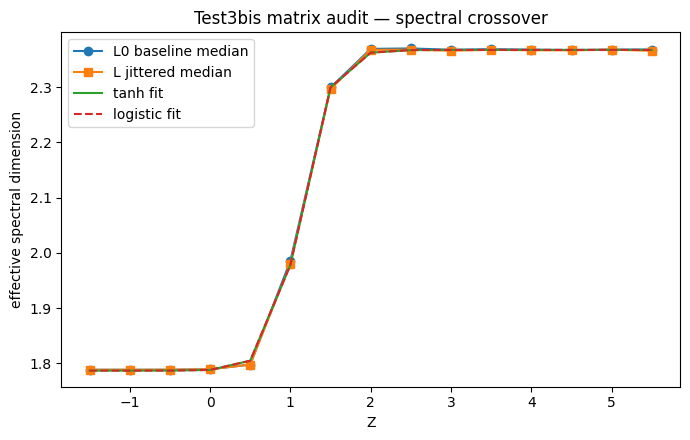

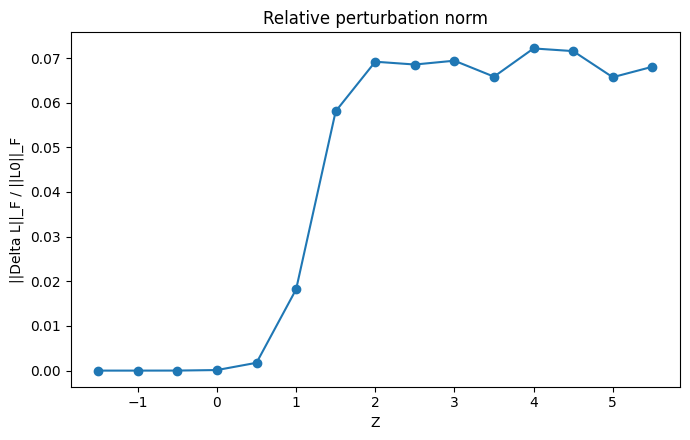

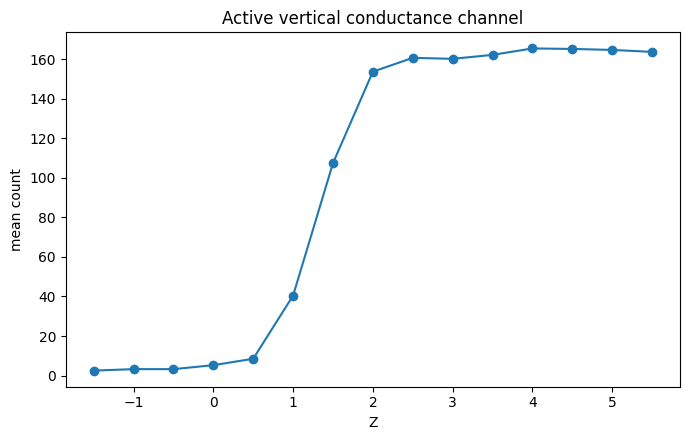

In [10]:

# ============================================================
# 10. Figures
# ============================================================
plt.figure(figsize=(7, 4.5))
plt.plot(agg["Z"], agg["ds_median_L0"], "o-", label="L0 baseline median")
plt.plot(agg["Z"], agg["ds_median_L"], "s-", label="L jittered median")
if "tanh" in preds:
    plt.plot(preds["Z"], preds["tanh"], "-", label="tanh fit")
if "logistic" in preds:
    plt.plot(preds["Z"], preds["logistic"], "--", label="logistic fit")
plt.xlabel("Z")
plt.ylabel("effective spectral dimension")
plt.title("Test3bis matrix audit — spectral crossover")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "spectral_crossover_L0_vs_L.png", dpi=170)
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(agg["Z"], agg["rel_DeltaL_fro"], "o-")
plt.xlabel("Z")
plt.ylabel("||Delta L||_F / ||L0||_F")
plt.title("Relative perturbation norm")
plt.tight_layout()
plt.savefig(FIG_DIR / "relative_DeltaL_fro.png", dpi=170)
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(agg["Z"], agg["active_vertical_edges"], "o-")
plt.xlabel("Z")
plt.ylabel("mean count")
plt.title("Active vertical conductance channel")
plt.tight_layout()
plt.savefig(FIG_DIR / "active_vertical_edges.png", dpi=170)
plt.show()


In [11]:

# ============================================================
# 11. Autotests
# ============================================================
def assert_close(a, b, tol, msg):
    if abs(a-b) > tol:
        raise AssertionError(f"{msg}: got {a}, expected {b}, tol={tol}")

Z_test = float(Z_GRID[len(Z_GRID)//2])
L0_t, L_t, D_t, edge_t = build_L0_L_DeltaL(Z_test, 0, CFG)

assert L0_t.shape == L_t.shape == D_t.shape, "Matrix shapes mismatch."
assert_close(sparse_fro_norm(D_t - (L_t - L0_t)), 0.0, 1e-10, "DeltaL identity failure")
assert_close(float(np.max(np.abs(np.asarray(L_t.sum(axis=1)).ravel()))), 0.0, 1e-10, "L row sums not zero")
assert_close(float(np.max(np.abs(np.asarray(L0_t.sum(axis=1)).ravel()))), 0.0, 1e-10, "L0 row sums not zero")
assert float(edge_t["conductance"].min()) >= 0.0, "Negative conductance found."
assert np.all(np.isfinite(edge_t["resistance"].replace(np.inf, np.nan).dropna())), "Non-finite finite resistances found."

assert (OUT_DIR / "test3bis_matrix_audit_raw.csv").exists(), "Raw export missing."
assert (OUT_DIR / "test3bis_matrix_audit_aggregated.csv").exists(), "Aggregated export missing."
assert (OUT_DIR / "test3bis_matrix_audit_fit_models.csv").exists(), "Fit export missing."
assert len(list(MATRIX_DIR.glob("**/*_L0.npz"))) > 0, "L0 npz exports missing."
assert len(list(MATRIX_DIR.glob("**/*_L.npz"))) > 0, "L npz exports missing."
assert len(list(MATRIX_DIR.glob("**/*_DeltaL.npz"))) > 0, "DeltaL npz exports missing."
assert len(list(MATRIX_DIR.glob("**/*_jittered_conductances.csv"))) > 0, "Conductance exports missing."

AUTOTEST_STATUS = {
    "passed": True,
    "Z_test": Z_test,
    "n_matrix_bundles": len(list(MATRIX_DIR.glob("*"))),
    "n_L0_exports": len(list(MATRIX_DIR.glob("**/*_L0.npz"))),
    "n_L_exports": len(list(MATRIX_DIR.glob("**/*_L.npz"))),
    "n_DeltaL_exports": len(list(MATRIX_DIR.glob("**/*_DeltaL.npz"))),
    "n_conductance_exports": len(list(MATRIX_DIR.glob("**/*_jittered_conductances.csv"))),
}

with open(OUT_DIR / "AUTOTEST_STATUS.json", "w", encoding="utf-8") as f:
    json.dump(AUTOTEST_STATUS, f, indent=2)

print(json.dumps(AUTOTEST_STATUS, indent=2))


{
  "passed": true,
  "Z_test": 2.0,
  "n_matrix_bundles": 60,
  "n_L0_exports": 60,
  "n_L_exports": 60,
  "n_DeltaL_exports": 60,
  "n_conductance_exports": 60
}


In [12]:

# ============================================================
# 12. Matrix index and report
# ============================================================
index_rows = []
for stats_path in sorted(MATRIX_DIR.glob("**/*_matrix_stats.csv")):
    try:
        df = pd.read_csv(stats_path)
        df["stats_path"] = str(stats_path.relative_to(OUT_DIR))
        index_rows.append(df)
    except Exception:
        pass

matrix_index = pd.concat(index_rows, ignore_index=True) if index_rows else pd.DataFrame()
matrix_index.to_csv(OUT_DIR / "MATRIX_EXPORT_INDEX.csv", index=False)

best = fit_df.iloc[0].to_dict()
report = {
    "title": "Track 3bis — heat-kernel broadening with matrix audit",
    "status": "completed" if AUTOTEST_STATUS.get("passed") else "failed_autotests",
    "configuration": asdict(CFG),
    "best_fit_model": best.get("model"),
    "best_fit_params": str(best.get("params")),
    "exports": {
        "raw": "test3bis_matrix_audit_raw.csv",
        "aggregated": "test3bis_matrix_audit_aggregated.csv",
        "fit_models": "test3bis_matrix_audit_fit_models.csv",
        "matrix_index": "MATRIX_EXPORT_INDEX.csv",
        "matrix_dir": "matrix_exports/",
    },
    "audit_chain": "jittered conductances -> L0, L, DeltaL -> eigenvalues/heat trace -> ds_eff",
    "safe_claim": "The discrete perturbation chain is auditable through exported L0, L, DeltaL and local conductances.",
    "not_claimed": "This is not a proof of a continuum limit or a closed analytical Kigami convergence theorem.",
    "autotests": AUTOTEST_STATUS,
}

with open(OUT_DIR / "TEST3BIS_MATRIX_AUDIT_REPORT.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print(json.dumps(report, indent=2)[:3000])


{
  "title": "Track 3bis \u2014 heat-kernel broadening with matrix audit",
  "status": "completed",
  "configuration": {
    "n_subdiv": 3,
    "layers": 4,
    "torus_xy": true,
    "torus_layers": false,
    "z_min": -1.5,
    "z_max": 5.5,
    "n_z": 15,
    "n_realizations": 4,
    "w_plane": 1.0,
    "w_vertical_hi": 1.0,
    "w_vertical_lo": 0.0,
    "Z_th_RG": 1.328,
    "Delta_Z_RG": 0.515,
    "p_low_floor": 0.015,
    "p_high": 0.85,
    "jitter_sigma": 0.25,
    "hier_jitter_power": 1.0,
    "normalize_active_vertical_mean": true,
    "u_min": 0.08,
    "u_max": 80.0,
    "n_u": 34,
    "heat_window_q_low": 0.2,
    "heat_window_q_high": 0.8,
    "use_median_ds": true,
    "export_matrices": true,
    "export_eigenvalues": true,
    "export_heat_trace_local": true
  },
  "best_fit_model": "tanh",
  "best_fit_params": "[1.786765369151907, 2.3676750512151297, 1.1300295028126266, 0.3657732396826079]",
  "exports": {
    "raw": "test3bis_matrix_audit_raw.csv",
    "aggregated": 

In [13]:

# ============================================================
# 13. ZIP export
# ============================================================
def zip_outputs(out_dir=OUT_DIR):
    zip_path = out_dir / "piste3bis_matrix_audit_outputs.zip"
    include_suffix = {".csv", ".json", ".png", ".npz", ".txt"}
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for p in sorted(out_dir.rglob("*")):
            if p.is_file() and p.name != zip_path.name and p.suffix.lower() in include_suffix:
                zf.write(p, arcname=str(p.relative_to(out_dir)))
    return zip_path

zip_path = zip_outputs(OUT_DIR)

manifest = []
with zipfile.ZipFile(zip_path, "r") as zf:
    for info in zf.infolist():
        manifest.append({"filename": info.filename, "file_size": info.file_size, "compress_size": info.compress_size})

with open(OUT_DIR / "ZIP_MANIFEST.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

# Rebuild ZIP to include manifest.
zip_path = zip_outputs(OUT_DIR)

print("ZIP:", zip_path)
print("ZIP size bytes:", zip_path.stat().st_size)
print("Number of files in ZIP:", len(manifest))
print("In Colab, download with: files.download(str(zip_path))")


ZIP: /content/drive/MyDrive/ROSG_Test3bis/piste3bis_matrix_audit_outputs/piste3bis_matrix_audit_outputs.zip
ZIP size bytes: 1843925
Number of files in ZIP: 551
In Colab, download with: files.download(str(zip_path))


In [14]:

# ============================================================
# 14. Optional Colab download
# ============================================================
DOWNLOAD_ZIP = False
if IN_COLAB and DOWNLOAD_ZIP:
    files.download(str(OUT_DIR / "piste3bis_matrix_audit_outputs.zip"))
